In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ── Inladen ──────────────────────────────────────────────────────────────────
df = pd.read_excel('energie_orac_2024.xlsx')         # pas aan naar jouw bestandsnaam

df.head(10)

,datetime,afname_kwh,injectie_kwh,productie_kwh
0,2024-01-01 00:00:00,10.625,0.0,-0.053734
1,2024-01-01 00:15:00,10.625,0.0,-0.053734
2,2024-01-01 00:30:00,11.875,0.0,-0.053734
3,2024-01-01 00:45:00,13.750,0.0,-0.053734
4,2024-01-01 01:00:00,14.375,0.0,-0.053734
5,2024-01-01 01:15:00,13.125,0.0,-0.053410
6,2024-01-01 01:30:00,13.750,0.0,-0.053351
7,2024-01-01 01:45:00,13.125,0.0,-0.053403
8,2024-01-01 02:00:00,12.500,0.0,-0.053501
9,2024-01-01 02:15:00,13.125,0.0,-0.053813


In [4]:
#als productie negatief is naar 0 zetten
df['productie_kwh'] = df['productie_kwh'].apply(lambda x: max(x, 0))

In [5]:
df["totaalverbruik"] = df["afname_kwh"] + df["productie_kwh"] - df["injectie_kwh"]

df.head()

,datetime,afname_kwh,injectie_kwh,productie_kwh,totaalverbruik
0,2024-01-01 00:00:00,10.625,0.0,0.0,10.625
1,2024-01-01 00:15:00,10.625,0.0,0.0,10.625
2,2024-01-01 00:30:00,11.875,0.0,0.0,11.875
3,2024-01-01 00:45:00,13.750,0.0,0.0,13.750
4,2024-01-01 01:00:00,14.375,0.0,0.0,14.375


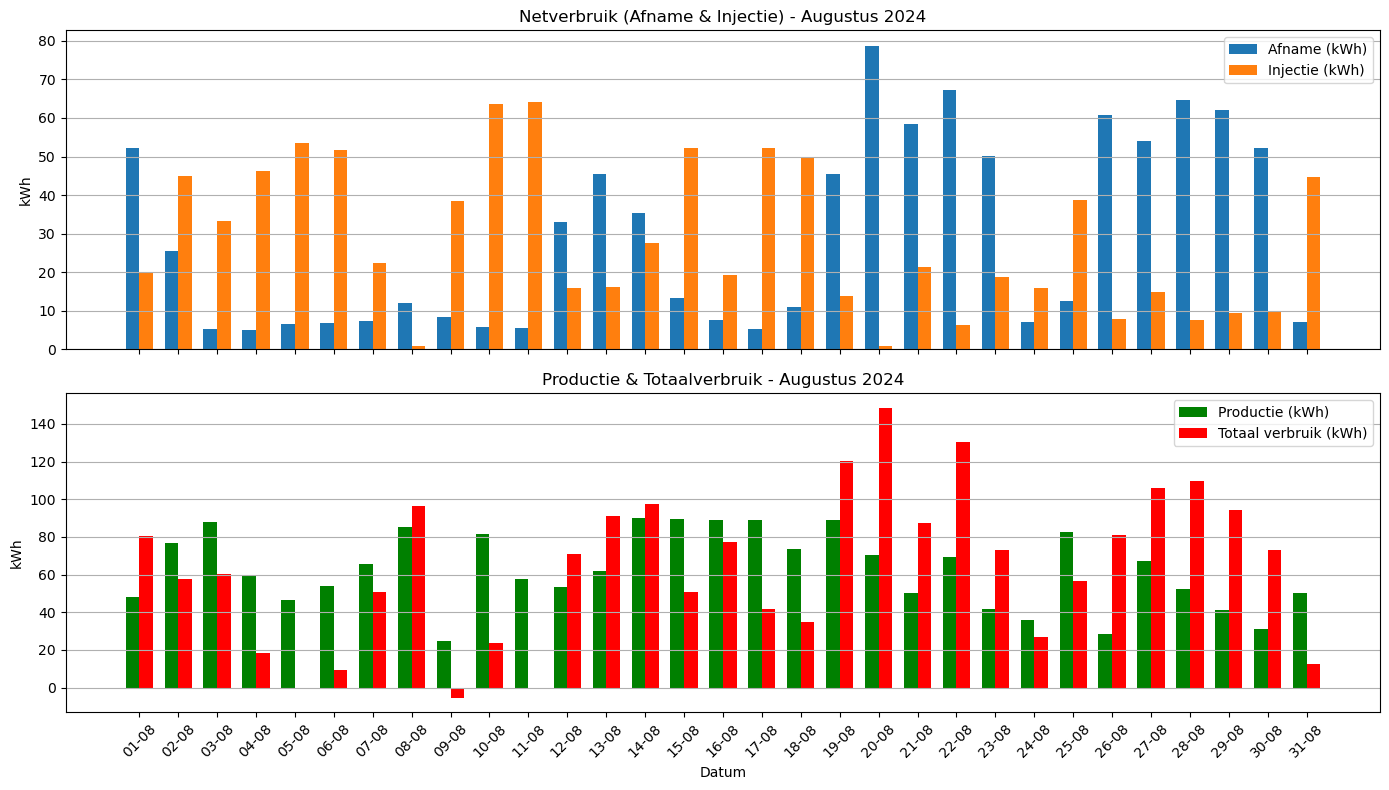

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Zorg dat datetime correct is
df['datetime'] = pd.to_datetime(df['datetime'])

# Filter augustus 2024
df_aug = df[(df['datetime'].dt.year == 2024) & (df['datetime'].dt.month == 8)]

# Resample per dag
df_aug = df_aug.set_index('datetime').resample('D').mean().reset_index()

# Breedte van de bars
width = 0.35

# Maak subplots
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# X-posities
x = range(len(df_aug))

# --- Netverbruik (Afname + Injectie)
ax[0].bar(
    [i - width/2 for i in x],
    df_aug['afname_kwh'],
    width=width,
    label='Afname (kWh)'
)

ax[0].bar(
    [i + width/2 for i in x],
    df_aug['injectie_kwh'],
    width=width,
    label='Injectie (kWh)'
)

ax[0].set_title('Netverbruik (Afname & Injectie) - Augustus 2024')
ax[0].set_ylabel('kWh')
ax[0].legend()
ax[0].grid(axis='y')

# --- Productie + totaalverbruik
ax[1].bar(
    [i - width/2 for i in x],
    df_aug['productie_kwh'],
    width=width,
    label='Productie (kWh)',
    color='green'
)

ax[1].bar(
    [i + width/2 for i in x],
    df_aug['totaalverbruik'],
    width=width,
    label='Totaal verbruik (kWh)',
    color='red'
)

ax[1].set_title('Productie & Totaalverbruik - Augustus 2024')
ax[1].set_xlabel('Datum')
ax[1].set_ylabel('kWh')
ax[1].legend()
ax[1].grid(axis='y')

# Datums als labels
ax[1].set_xticks(list(x))
ax[1].set_xticklabels(
    df_aug['datetime'].dt.strftime('%d-%m'),
    rotation=45
)

plt.tight_layout()
plt.show()

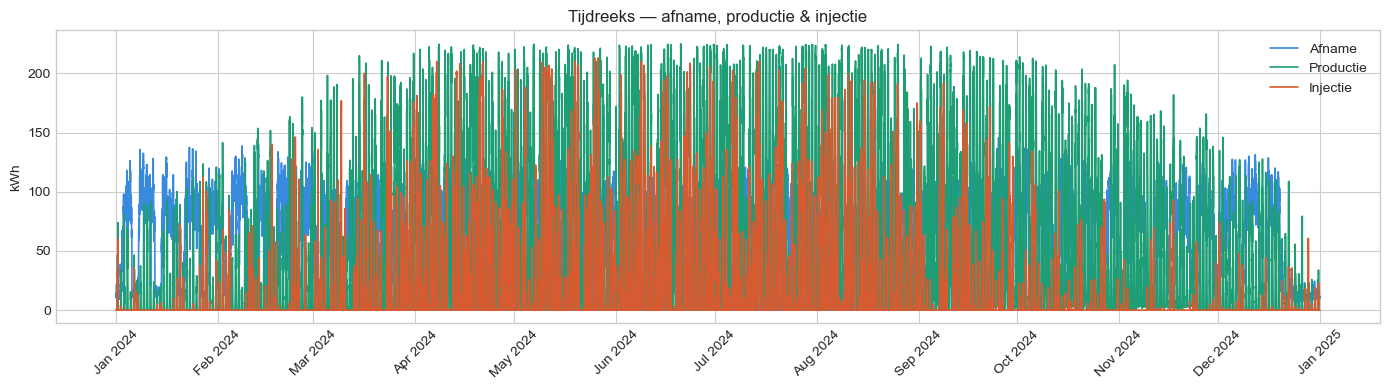

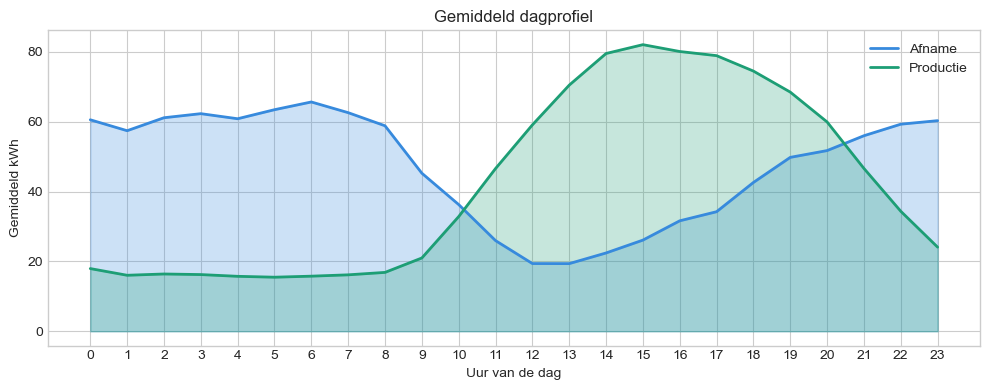

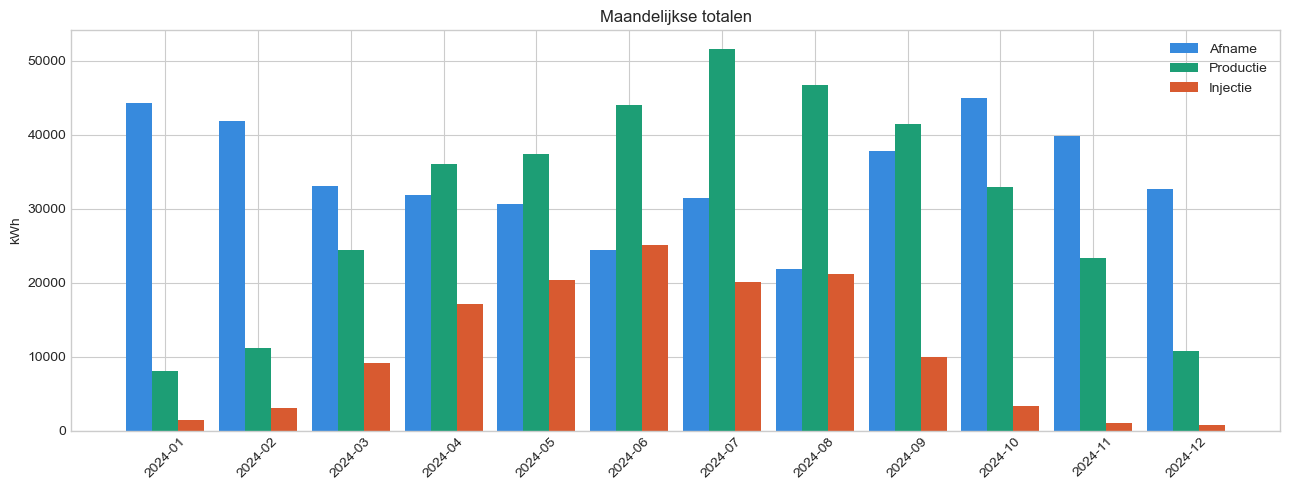

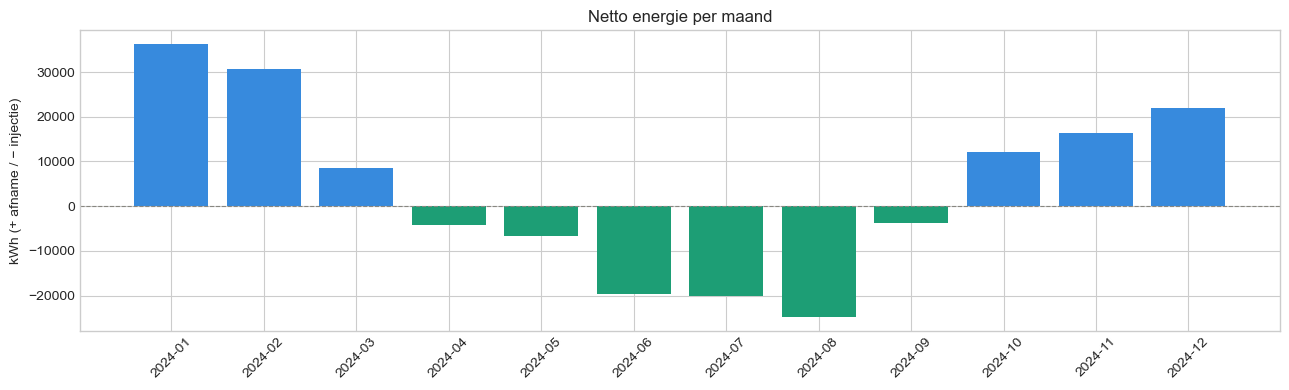

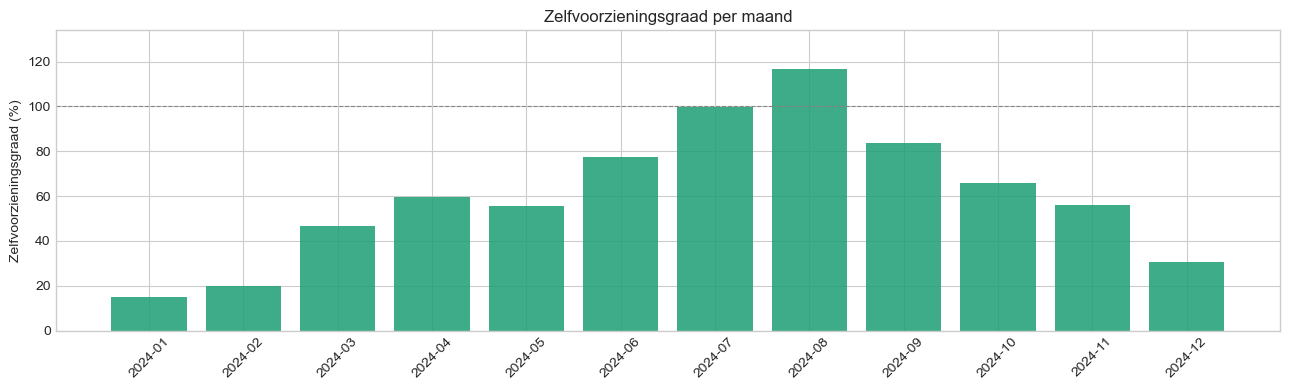

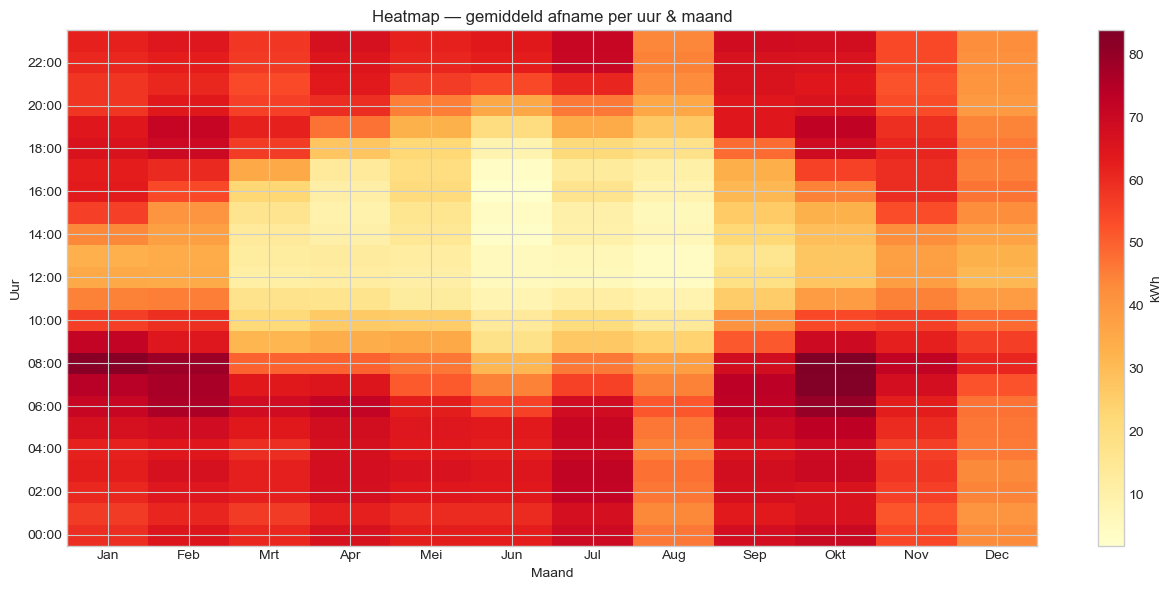

✓ Alle grafieken aangepast aan nieuwe kolomnamen.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

# Afgeleide kolommen
df["Netto (kWh)"] = df["afname_kwh"] - df["productie_kwh"]
df["Maand"] = df["datetime"].dt.to_period("M")
df["Uur"] = df["datetime"].dt.hour + df["datetime"].dt.minute / 60

# ── Stijl ─────────────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
BLAUW   = "#378ADD"
GROEN   = "#1D9E75"
ORANJE  = "#D85A30"
GRIJS   = "#888780"

# ═══════════════════════════════════════════════════════════════════════════════
# 1. TIJDREEKS — afname, productie en injectie
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["datetime"], df["afname_kwh"],     color=BLAUW,  lw=1.2, label="Afname")
ax.plot(df["datetime"], df["productie_kwh"],  color=GROEN,  lw=1.2, label="Productie")
ax.plot(df["datetime"], df["injectie_kwh"],   color=ORANJE, lw=1.2, label="Injectie")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

ax.set_ylabel("kWh")
ax.set_title("Tijdreeks — afname, productie & injectie")
ax.legend()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. GEMIDDELD DAGPROFIEL per uur
# ═══════════════════════════════════════════════════════════════════════════════
dagprofiel = df.groupby(df["datetime"].dt.hour)[
    ["afname_kwh", "productie_kwh"]
].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(dagprofiel.index, dagprofiel["afname_kwh"], alpha=0.25, color=BLAUW)
ax.fill_between(dagprofiel.index, dagprofiel["productie_kwh"], alpha=0.25, color=GROEN)

ax.plot(dagprofiel.index, dagprofiel["afname_kwh"], color=BLAUW, lw=2, label="Afname")
ax.plot(dagprofiel.index, dagprofiel["productie_kwh"], color=GROEN, lw=2, label="Productie")

ax.set_xticks(range(0, 24))
ax.set_xlabel("Uur van de dag")
ax.set_ylabel("Gemiddeld kWh")
ax.set_title("Gemiddeld dagprofiel")
ax.legend()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 3. MAANDELIJKSE TOTALEN (kWh)
# ═══════════════════════════════════════════════════════════════════════════════
maand = df.groupby("Maand")[
    ["afname_kwh", "productie_kwh", "injectie_kwh"]
].sum() / 4   # 15-minuten → kWh

maand.index = maand.index.astype(str)
x = np.arange(len(maand))
breedte = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - breedte, maand["afname_kwh"],    breedte, label="Afname",   color=BLAUW)
ax.bar(x,           maand["productie_kwh"], breedte, label="Productie",color=GROEN)
ax.bar(x + breedte, maand["injectie_kwh"],  breedte, label="Injectie", color=ORANJE)

ax.set_xticks(x)
ax.set_xticklabels(maand.index, rotation=45)
ax.set_ylabel("kWh")
ax.set_title("Maandelijkse totalen")
ax.legend()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. NETTO ENERGIE per maand
# ═══════════════════════════════════════════════════════════════════════════════
maand_netto = df.groupby("Maand")["Netto (kWh)"].sum() / 4
maand_netto.index = maand_netto.index.astype(str)

kleuren = [BLAUW if v >= 0 else GROEN for v in maand_netto]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(maand_netto.index, maand_netto, color=kleuren)
ax.axhline(0, color=GRIJS, lw=0.8, linestyle="--")

ax.set_ylabel("kWh (+ afname / − injectie)")
ax.set_title("Netto energie per maand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. ZELFVOORZIENINGSGRAAD per maand (%)
# ═══════════════════════════════════════════════════════════════════════════════
maand_v = df.groupby("Maand")["afname_kwh"].sum()
maand_p = df.groupby("Maand")["productie_kwh"].sum()
maand_i = df.groupby("Maand")["injectie_kwh"].sum()

zelfverbruik = (maand_p - maand_i).clip(lower=0)
zvg = (zelfverbruik / maand_v * 100).fillna(0)
zvg.index = zvg.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(zvg.index, zvg, color=GROEN, alpha=0.85)
ax.axhline(100, color=GRIJS, lw=0.8, linestyle="--")

ax.set_ylabel("Zelfvoorzieningsgraad (%)")
ax.set_title("Zelfvoorzieningsgraad per maand")
ax.set_ylim(0, max(zvg.max() * 1.15, 10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. HEATMAP — gemiddeld uurverbruik per maand
# ═══════════════════════════════════════════════════════════════════════════════
df["Maand_nr"] = df["datetime"].dt.month
df["Uur_nr"] = df["datetime"].dt.hour

pivot = df.pivot_table(
    values="afname_kwh",
    index="Uur_nr",
    columns="Maand_nr",
    aggfunc="mean"
)

maand_namen = ["Jan","Feb","Mrt","Apr","Mei","Jun","Jul","Aug","Sep","Okt","Nov","Dec"]
pivot.columns = [maand_namen[m - 1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(pivot, aspect="auto", cmap="YlOrRd", origin="lower")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)

ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])

ax.set_xlabel("Maand")
ax.set_ylabel("Uur")
ax.set_title("Heatmap — gemiddeld afname per uur & maand")

plt.colorbar(im, ax=ax, label="kWh")
plt.tight_layout()
plt.show()

print("✓ Alle grafieken aangepast aan nieuwe kolomnamen.")

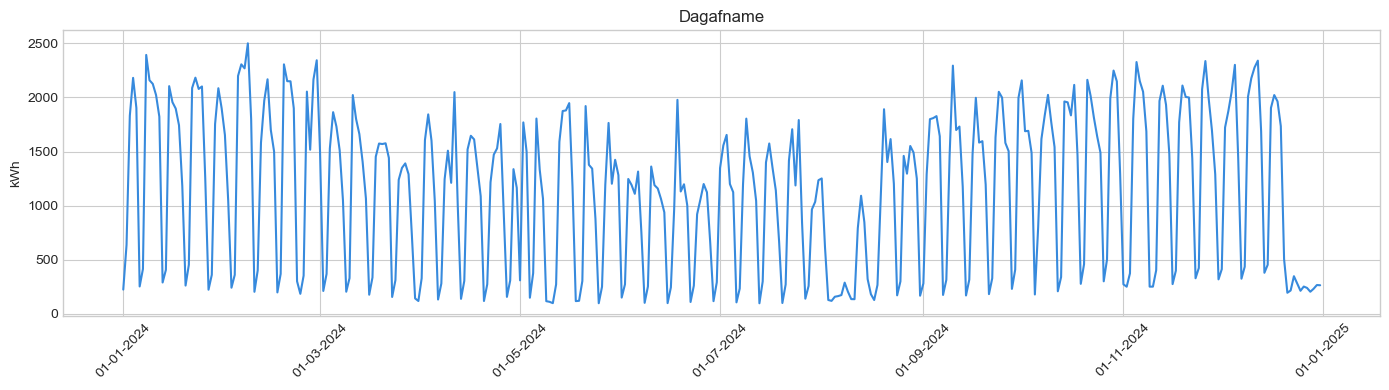

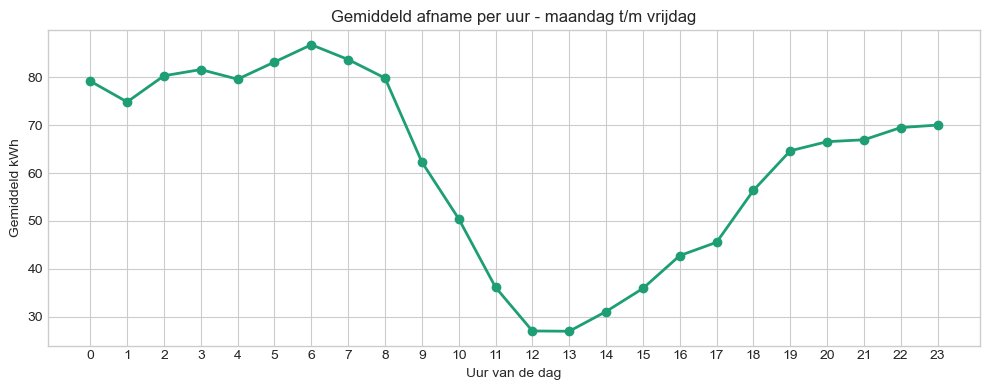

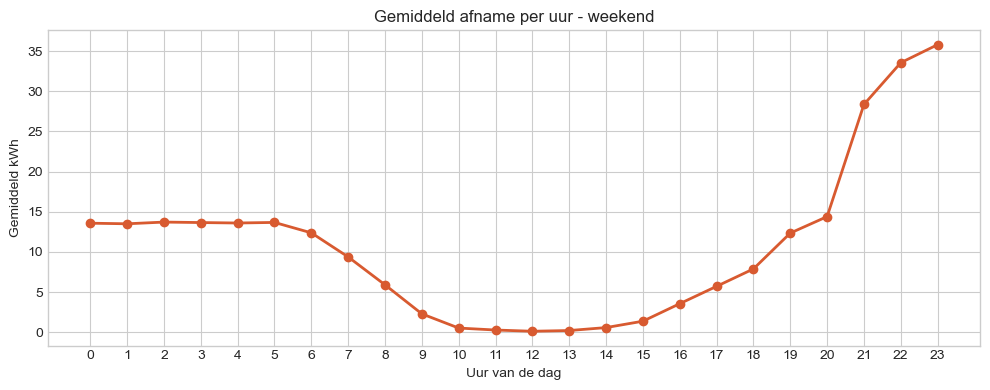

In [9]:
# Nieuwe verbruiksgrafieken op basis van nieuwe tabel
# - dagverbruik per kalenderdag
# - gemiddeld verbruik per uur op werkdagen
# - gemiddeld verbruik per uur in het weekend

df["datetime"] = pd.to_datetime(df["datetime"])
df["Dag"] = df["datetime"].dt.normalize()
df["Dagtype"] = np.where(df["datetime"].dt.dayofweek < 5, "Maandag-vrijdag", "Weekend")

# ─────────────────────────────────────────────────────────────
# 1. Verbruik per dag
# ─────────────────────────────────────────────────────────────
verbruik_per_dag = df.groupby("Dag")["afname_kwh"].sum() / 4

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(verbruik_per_dag.index, verbruik_per_dag.values, color=BLAUW, lw=1.5)

ax.set_title("Dagafname")
ax.set_ylabel("kWh")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# 2. Gemiddeld verbruik per uur op werkdagen
# ─────────────────────────────────────────────────────────────
verbruik_werkdagen = df[df["Dagtype"] == "Maandag-vrijdag"] \
    .groupby(df["datetime"].dt.hour)["afname_kwh"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(verbruik_werkdagen.index, verbruik_werkdagen.values,
        color=GROEN, lw=2, marker="o")

ax.set_xticks(range(0, 24))
ax.set_xlabel("Uur van de dag")
ax.set_ylabel("Gemiddeld kWh")
ax.set_title("Gemiddeld afname per uur - maandag t/m vrijdag")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# 3. Gemiddeld verbruik per uur in het weekend
# ─────────────────────────────────────────────────────────────
verbruik_weekend = df[df["Dagtype"] == "Weekend"] \
    .groupby(df["datetime"].dt.hour)["afname_kwh"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(verbruik_weekend.index, verbruik_weekend.values,
        color=ORANJE, lw=2, marker="o")

ax.set_xticks(range(0, 24))
ax.set_xlabel("Uur van de dag")
ax.set_ylabel("Gemiddeld kWh")
ax.set_title("Gemiddeld afname per uur - weekend")

plt.tight_layout()
plt.show()